In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [3]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [2]:
adult = fetch_openml(
    name = "adult",
    version = 2,
    as_frame=True
)

df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
print(df.workclass.unique)

<bound method Series.unique of 0             Private
1             Private
2           Local-gov
3             Private
4                 NaN
             ...     
48837         Private
48838         Private
48839         Private
48840         Private
48841    Self-emp-inc
Name: workclass, Length: 48842, dtype: category
Categories (8, object): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc',
                         'Self-emp-not-inc', 'State-gov', 'Without-pay']>


In [10]:
print(df['marital-status'].unique())

['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated', 'Married-spouse-absent', 'Married-AF-spouse']
Categories (7, object): ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse',
                         'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']


In [14]:
print(df['race'].unique())

['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Categories (5, object): ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']


In [15]:
print(df['sex'].unique())

['Male', 'Female']
Categories (2, object): ['Female', 'Male']


In [16]:
ll = LabelEncoder()
df['class'] = ll.fit_transform(df['class'])
df['workclass'] = ll.fit_transform(df['workclass'])
df['marital-status'] = ll.fit_transform(df['marital-status'])
df['race'] = ll.fit_transform(df['race'])
df['sex'] = ll.fit_transform(df['sex'])
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,3,226802,11th,7,4,Machine-op-inspct,Own-child,2,1,0,0,40,United-States,0
1,38,3,89814,HS-grad,9,2,Farming-fishing,Husband,4,1,0,0,50,United-States,0
2,28,1,336951,Assoc-acdm,12,2,Protective-serv,Husband,4,1,0,0,40,United-States,1
3,44,3,160323,Some-college,10,2,Machine-op-inspct,Husband,2,1,7688,0,40,United-States,1
4,18,8,103497,Some-college,10,4,NaN,Own-child,4,0,0,0,30,United-States,0


In [4]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


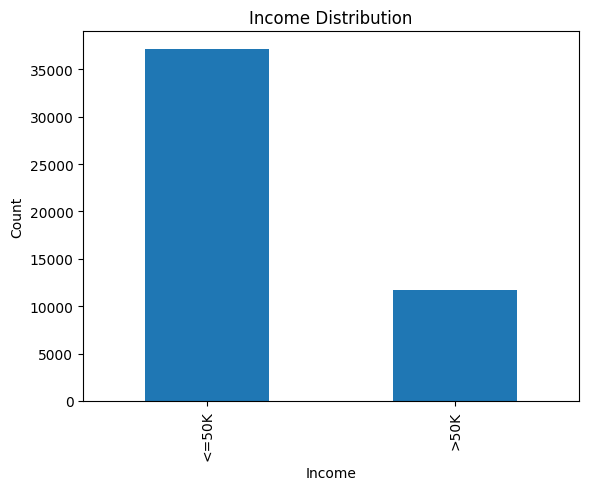

In [5]:
df["class"].value_counts().plot(kind="bar")

plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Income Distribution")
plt.show()

In [17]:
x = df.drop(['class','age','relationship'],axis = 1)
y = df['class']

In [19]:
x.value_counts()

workclass  fnlwgt  education     education-num  marital-status  occupation         race  sex  capital-gain  capital-loss  hours-per-week  native-country
3          255252  HS-grad       9              4               Craft-repair       4     1    0             0             40              United-States     3
           243368  Preschool     1              4               Farming-fishing    4     1    0             0             50              Mexico            3
           195994  1st-4th       2              4               Priv-house-serv    4     0    0             0             40              Guatemala         3
           184659  HS-grad       9              2               Machine-op-inspct  4     1    0             0             40              United-States     3
           308144  Bachelors     13             4               Craft-repair       4     1    0             0             40              Mexico            3
                                                                                                                                                           ..
           139850  Masters       14             2               Exec-managerial    1     1    0             0             45              United-States     1
           139863  1st-4th       2              4               Farming-fishing    4     1    0             0             40              Mexico            1
           139890  Some-college  10             0               Adm-clerical       4     0    0             0             40              United-States     1
           139903  Bachelors     13             4               Machine-op-inspct  2     0    0             0             40              United-States     1
           139770  HS-grad       9              4               Adm-clerical       4     0    6849          0             40              United-States     1
Name: count, Length: 45027, dtype: int64

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify=y)

In [25]:
numerical_cols_x_train = x_train.select_dtypes(
    include=["int64", "float64"]
).columns
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols_x_train
        )])

In [27]:
numerical_cols_x_test = x_test.select_dtypes(
    include=["int64", "float64"]
).columns
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols_x_test
        )])

In [31]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

logistic_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['workclass', 'fnlwgt', 'education-num', 'marital-status', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [32]:
logistic_model.score(x_train,y_train)

0.8218974739589998

In [33]:
logistic_model.score(x_test,y_test)

0.8236257549390931

In [35]:
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['workclass', 'fnlwgt', 'education-num', 'marital-status', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [36]:
rf_model.score(x_train,y_train)

0.997722212269342

In [37]:
rf_model.score(x_test,y_test)

0.8280274337189067

In [40]:
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])
xgb_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['workclass', 'fnlwgt', 'education-num', 'marital-status', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsamp...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [41]:
xgb_model.score(x_train,y_train)

0.8708315204872931

In [42]:
xgb_model.score(x_test,y_test)

0.8654928856587163

In [44]:
print(classification_report(y_test,xgb_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.79      0.60      0.68      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.77      0.80      9769
weighted avg       0.86      0.87      0.86      9769



In [46]:
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['workclass', 'fnlwgt', 'education-num', 'marital-status', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsamp...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=400,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [48]:
y_pred = xgb_model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7431
           1       0.58      0.86      0.69      2338

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.81      0.83      9769



In [50]:
from sklearn.model_selection import RandomizedSearchCV
params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__min_child_weight": [1, 3, 5, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=params,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(x_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.9}
0.686892714573309


In [51]:
best_model = search.best_estimator_

In [53]:
y_pred = best_model.predict(x_test)

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87      7431
           1       0.58      0.85      0.69      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.82      0.83      9769

